# Etapa 3 — Catálogo de eventos principales y aislamiento de réplicas

---
> Conjunto de datos obtenido del Servicio Sismológico Nacional, adscrito al Instituto de Geofísica de la Universidad Nacional Autónoma de México

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [16]:
df = pd.read_parquet('seismos_clean.parquet')

# Quitar TZ (mantiene valores UTC) para simplificar aritmética de tiempos
df['datetime_utc'] = df['datetime_utc'].dt.tz_convert(None)

# ID estable para deduplicación posterior
df['event_id'] = np.arange(len(df))

# Categoría de profundidad (no se guardó en Etapa 1)
def cat_prof(p):
    if pd.isna(p): 
        return 'Desconocida'
    elif p < 70:   
        return 'Superficial'
    elif p <= 300: 
        return 'Intermedio'
    else:          
        return 'Profundo'

df['categoria_prof'] = df['Profundidad'].apply(cat_prof)

print(f'Catálogo completo: {len(df):,}')
print(f'Sobre Mc: {df["sobre_Mc"].sum():,}')
print(f'Rango: {df["datetime_utc"].min().date()} -> {df["datetime_utc"].max().date()}')

Catálogo completo: 368,895
Sobre Mc: 232,270
Rango: 1974-01-04 -> 2026-06-20


Haremos uso de las ventanas de Gardner y Knopoff (1974), un algoritmo sismológico de declustering. Su función es separar los sismos principales de las réplicas o sismos dependientes, basándose en el principio de que eventos más grandes generan réplicas que ocurren dentro de un radio espacial y un período de tiempo determinados. El objetivo es crear un catálogo depurado que contenga únicamente sismos independientes.

Para esto, haremos uso también de la Distancia Haversine, que calcula la distancia más corta en línea recta entre dos puntos sobre una esfera utilizando su latitud y longitud. La distancia se calcula resolviendo:

$$d = 2 \cdot R \cdot \operatorname{arcsen}\left(\sqrt{\operatorname{sen}^2\left(\frac{\Delta\phi}{2}\right) + \cos(\phi_1) \cdot \cos(\phi_2) \cdot \operatorname{sen}^2\left(\frac{\Delta\lambda}{2}\right)}\right)$$

Donde:
* $R\approx 6,371 $ Km es el radio de la tierra
* $\phi$ es la latitud, $\lambda$ la longitud
* $\Delta\phi=\phi_2 - \phi_2$
* $\Delta\lambda = \lambda_2 - \lambda_1$

In [17]:
def gk_time_days(M):
    """Ventana temporal G-K (1974) en días."""
    return 10**(0.032*M + 2.7389) if M >= 6.5 else 10**(0.5*M - 1.67)

def gk_dist_km(M):
    """Ventana espacial G-K (1974) / Uhrhammer (1986) en km."""
    return 10**(0.443*M - 0.133) if M >= 6.5 else 10**(0.1238*M + 0.983)

def haversine_vec(lat1_arr, lon1_arr, lat2, lon2):
    """Distancias en km desde un arreglo de puntos a un punto de referencia."""
    R = 6371.0
    la1 = np.radians(np.asarray(lat1_arr, dtype=float))
    lo1 = np.radians(np.asarray(lon1_arr, dtype=float))
    la2, lo2 = np.radians(float(lat2)), np.radians(float(lon2))
    a = np.sin((la2-la1)/2)**2 + np.cos(la1)*np.cos(la2)*np.sin((lo2-lo1)/2)**2
    return R * 2 * np.arcsin(np.sqrt(np.clip(a, 0, 1)))

# Ventanas representativas
print(f'{"Magnitud":>10} {"Tiempo (días)":>15} {"Distancia (km)":>15}')
print('-' * 42)
for M in [5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.2]:
    print(f'  M {M:<6}  {gk_time_days(M):>12.0f}   {gk_dist_km(M):>12.0f}')

# Parámetros de relajación del declustering
DELTA_MAG = 0.5    # brecha mínima de magnitud para clasificar una réplica
MAX_TIME_DAYS = 365.0  # tope de ventana temporal (días)
MAX_DIST_KM = 500.0  # tope de ventana espacial (km)

  Magnitud   Tiempo (días)  Distancia (km)
------------------------------------------
  M 5.5               12             46
  M 6.0               21             53
  M 6.5              885            558
  M 7.0              918            929
  M 7.5              953           1547
  M 8.0              988           2576
  M 8.2             1003           3159


Entre los 1,820 candidatos M≥5.5, descartamos los que caen dentro de la ventana
G-K de un evento anterior y mayor. El restante es nuestro catálogo de mainshocks.

In [18]:
M55 = (
    df[df['Magnitud'] >= 5.5]
    .sort_values('datetime_utc')
    .reset_index(drop=True)
)
print(f'Candidatos M≥5.5: {len(M55)}')

# Arrays numpy para velocidad
lats   = M55['Latitud'].values
lons   = M55['Longitud'].values
mags   = M55['Magnitud'].values
times  = M55['datetime_utc'].values.astype('datetime64[ns]').view('int64')  # nanosegundos
gk_T_ns = np.array([min(gk_time_days(m), MAX_TIME_DAYS) * 86400 * 1e9 for m in mags], dtype='int64')
gk_D    = np.array([min(gk_dist_km(m), MAX_DIST_KM) for m in mags])

is_aftershock = np.zeros(len(M55), dtype=bool)
parent_pos    = np.full(len(M55), -1)

for i in range(1, len(M55)):
    # Mainshocks previos con magnitud al menos DELTA_MAG mayor que el evento i
    prev_main = (~is_aftershock[:i]) & (mags[:i] >= mags[i] + DELTA_MAG)
    if not np.any(prev_main):
        continue

    # Filtro temporal
    dt_ns = times[i] - times[:i]
    time_ok = prev_main & (dt_ns > 0) & (dt_ns <= gk_T_ns[:i])
    if not np.any(time_ok):
        continue

    # Filtro espacial: calcular distancias solo a los candidatos temporales
    j_idxs = np.where(time_ok)[0]
    dists  = haversine_vec(lats[j_idxs], lons[j_idxs], lats[i], lons[i])
    dist_ok = dists <= gk_D[j_idxs]
    if not np.any(dist_ok):
        continue

    # Asignar al mainshock más cercano
    valid_j   = j_idxs[dist_ok]
    nearest   = valid_j[np.argmin(dists[dist_ok])]
    is_aftershock[i] = True
    parent_pos[i]    = nearest

mainshocks = M55[~is_aftershock].copy().reset_index(drop=True)
mainshocks.index.name = 'mainshock_id'
mainshocks = mainshocks.reset_index()

print(f'\nEventos principales identificados: {len(mainshocks)}')
print(f'Descartados como réplicas (M≥5.5): {is_aftershock.sum()}')
print(f'\nDistribución por magnitud:')
bins = [5.5, 6.0, 6.5, 7.0, 7.5, 8.3]
print(pd.cut(mainshocks['Magnitud'], bins=bins, right=False).value_counts().sort_index())

Candidatos M≥5.5: 492

Eventos principales identificados: 305
Descartados como réplicas (M≥5.5): 187

Distribución por magnitud:
Magnitud
[5.5, 6.0)    176
[6.0, 6.5)     58
[6.5, 7.0)     44
[7.0, 7.5)     19
[7.5, 8.3)      8
Name: count, dtype: int64


Realizamos una recolección de réplicas por mainshock:

In [19]:
print('Recolectando réplicas para cada mainshock...')
replicas_list = []

for _, ms in mainshocks.iterrows():
    t0   = ms['datetime_utc']
    t1   = t0 + pd.Timedelta(days=min(gk_time_days(ms['Magnitud']), MAX_TIME_DAYS))
    D_km = min(gk_dist_km(ms['Magnitud']), MAX_DIST_KM)

    # Filtro temporal sobre catálogo completo
    time_mask = (df['datetime_utc'] > t0) & (df['datetime_utc'] <= t1)
    cands = df[time_mask]
    if len(cands) == 0:
        continue

    # Filtro espacial
    dists = haversine_vec(cands['Latitud'].values, cands['Longitud'].values, ms['Latitud'], ms['Longitud'])
    dist_mask = dists <= D_km
    rep = cands[dist_mask].copy()
    rep['mainshock_id'] = ms['mainshock_id']
    rep['dist_km'] = dists[dist_mask]
    rep['dt_horas'] = (rep['datetime_utc'] - t0).dt.total_seconds() / 3600
    replicas_list.append(rep)

if replicas_list:
    all_replicas_raw = pd.concat(replicas_list, ignore_index=True)
else:
    all_replicas_raw = pd.DataFrame()

print(f'Pares evento-mainshock (antes de dedup): {len(all_replicas_raw):,}')

Recolectando réplicas para cada mainshock...
Pares evento-mainshock (antes de dedup): 206,833


Asignamos al mainshock más cercano para reducir solapamiento:

In [20]:
# Ordenar por distancia: el primero de cada event_id es el mainshock más cercano
replicas = (
    all_replicas_raw
    .sort_values('dist_km')
    .drop_duplicates(subset=['event_id'], keep='first')
    .sort_values(['mainshock_id', 'dt_horas'])
    .reset_index(drop=True)
)

print(f'Réplicas únicas asignadas: {len(replicas):,}')
print(f'Mainshocks con ≥1 réplica: {replicas["mainshock_id"].nunique()}')
print(f'Mainshocks sin réplicas detectadas: {len(mainshocks) - replicas["mainshock_id"].nunique()}')

Réplicas únicas asignadas: 159,614
Mainshocks con ≥1 réplica: 233
Mainshocks sin réplicas detectadas: 72


Construimos la tabla de features y targets:

In [21]:
records = []

for _, ms in mainshocks.iterrows():
    ms_id = ms['mainshock_id']
    seq   = replicas[replicas['mainshock_id'] == ms_id]

    # Actividad en la primera hora (features de entrada al modelo)
    early = seq[(seq['dt_horas'] > 0) & (seq['dt_horas'] <= 1) & seq['sobre_Mc']]

    # Réplicas sobre Mc en ventanas de predicción
    rep_24h = seq[(seq['dt_horas'] > 0) & (seq['dt_horas'] <= 24) & seq['sobre_Mc']]
    rep_48h = seq[(seq['dt_horas'] > 0) & (seq['dt_horas'] <= 48) & seq['sobre_Mc']]

    records.append({
        # Identificación
        'mainshock_id': ms_id,
        'datetime_utc': ms['datetime_utc'],
        'year': ms['year'],
        # Features en t=0
        'magnitud': ms['Magnitud'],
        'profundidad': ms['Profundidad'],
        'latitud': ms['Latitud'],
        'longitud': ms['Longitud'],
        'categoria_prof': ms['categoria_prof'],
        'estado': ms['estado'],
        'hora_local': ms['hora_local'],
        'Mc_epoca': ms['Mc_epoca'],
        # Features de actividad temprana (primera hora)
        'n_replicas_1h': len(early),
        'mag_max_1h': early['Magnitud'].max() if len(early) > 0 else np.nan,
        'tasa_1h': float(len(early)),   # réplicas/hora
        # Targets
        'n_replicas_24h': len(rep_24h), # target principal
        'n_replicas_48h': len(rep_48h),
        'mag_max_48h': rep_48h['Magnitud'].max() if len(rep_48h) > 0 else np.nan,
    })

corpus = pd.DataFrame(records)

print(f'Corpus total: {len(corpus)} mainshocks')
print(f'\n--- Target principal: n_replicas_24h ---')
print(corpus['n_replicas_24h'].describe().round(2))
print(f'\nSismos con 0 réplicas en 24h: {(corpus["n_replicas_24h"] == 0).sum()}')

Corpus total: 305 mainshocks

--- Target principal: n_replicas_24h ---
count    305.00
mean       9.76
std       31.28
min        0.00
25%        0.00
50%        1.00
75%        6.00
max      340.00
Name: n_replicas_24h, dtype: float64

Sismos con 0 réplicas en 24h: 117


In [22]:
n_raw = len(corpus)

# Observación incompleta: mainshocks en las últimas 48h del catálogo no tienen targets completos
cutoff_48h = df['datetime_utc'].max() - pd.Timedelta(hours=48)
mask_completo = corpus['datetime_utc'] <= cutoff_48h

# Mc conocida (primera época con pocos datos puede quedar sin estimación)
mask_mc = corpus['Mc_epoca'].notna()

corpus = corpus[mask_completo & mask_mc].reset_index(drop=True)

print(f'Corpus antes de filtros:                {n_raw}')
print(f'  Descartados (ventana 48h incompleta): {(~mask_completo).sum()}')
print(f'  Descartados (Mc no estimada):         {(~mask_mc).sum()}')
print(f'Corpus final para ML:                   {len(corpus)}')

Corpus antes de filtros:                305
  Descartados (ventana 48h incompleta): 0
  Descartados (Mc no estimada):         0
Corpus final para ML:                   305


Graficamos las réplicas de 3 eventos históricos relevantes para validar
que el declustering funcionó correctamente antes de pasar al modelado.

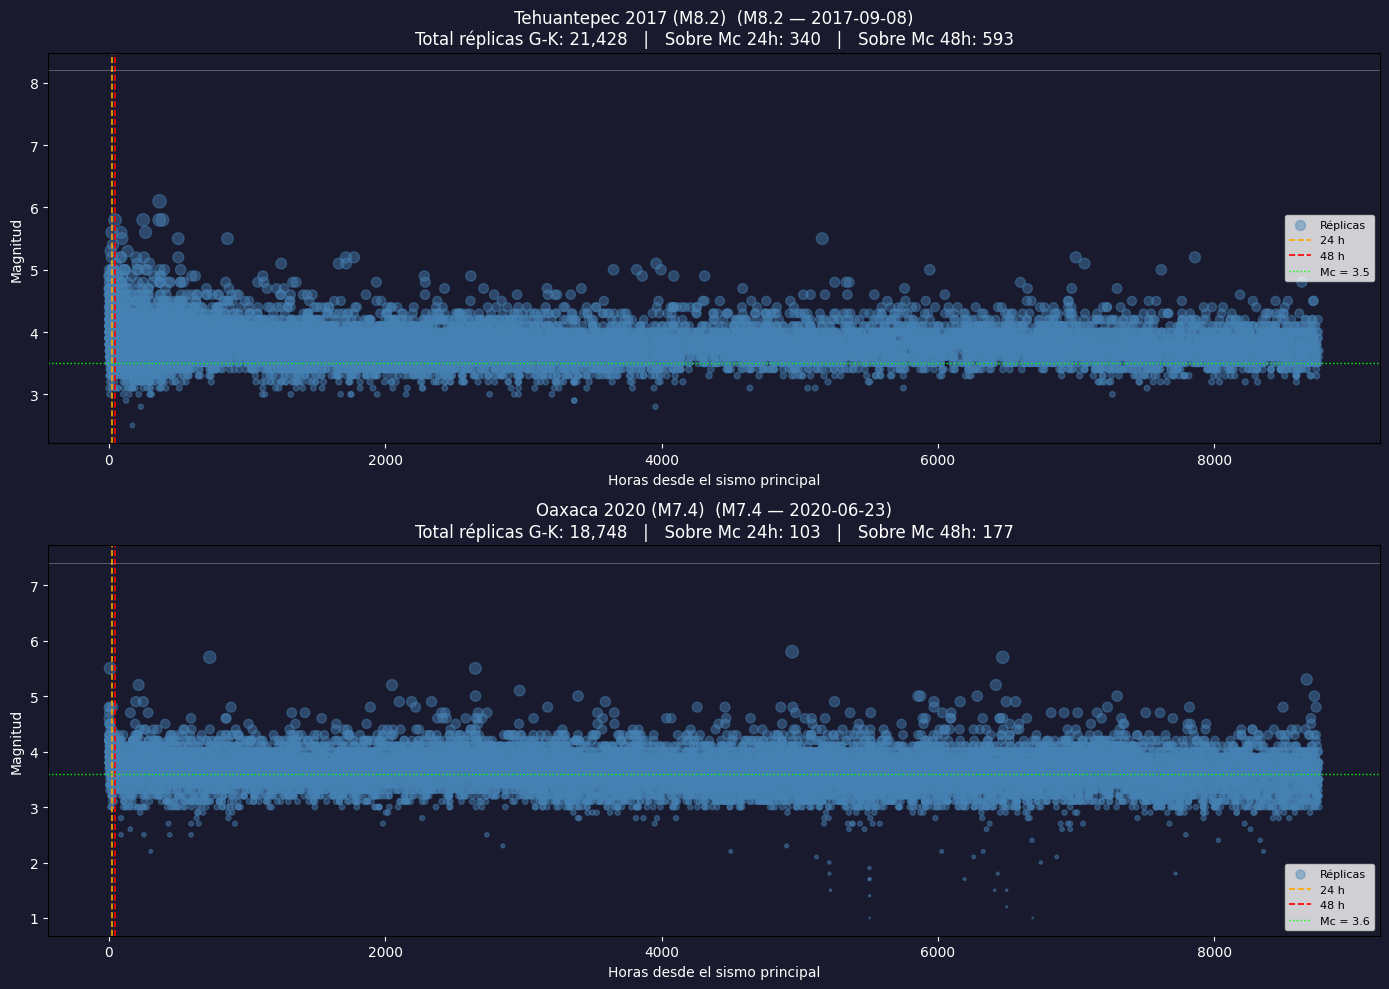

In [23]:
SECUENCIAS = {
    'Tehuantepec 2017 (M8.2)':    {'fecha': '2017-09-08', 'lat': 15.0, 'lon': -94.1},
    'Oaxaca 2020 (M7.4)':         {'fecha': '2020-06-23', 'lat': 15.8, 'lon': -96.1},
}

fig, axes = plt.subplots(len(SECUENCIAS), 1, figsize=(14, 5*len(SECUENCIAS)))

for ax, (nombre, info) in zip(axes, SECUENCIAS.items()):
    fecha_dt = pd.Timestamp(info['fecha'])

    # Buscar mainshock más grande dentro de ±2 días y ±2 grados
    match = corpus[
        (abs(corpus['latitud']  - info['lat']) < 2.0) &
        (abs(corpus['longitud'] - info['lon']) < 2.0) &
        (abs((corpus['datetime_utc'] - fecha_dt).dt.total_seconds()) < 2*86400)
    ].nlargest(1, 'magnitud')

    if match.empty:
        ax.set_title(f'{nombre} — NO encontrado en corpus ⚠️', color='red')
        ax.axis('off')
        continue

    ms_row = match.iloc[0]
    ms_id  = ms_row['mainshock_id']
    seq    = replicas[replicas['mainshock_id'] == ms_id]
    Mc     = ms_row['Mc_epoca']

    ax.scatter(seq['dt_horas'], seq['Magnitud'],
               s=seq['Magnitud']**2.5, alpha=0.45, color='steelblue', label='Réplicas')
    ax.axvline(24,  color='orange', linestyle='--', linewidth=1.2, label='24 h')
    ax.axvline(48,  color='red',    linestyle='--', linewidth=1.2, label='48 h')
    ax.axhline(Mc,  color='lime',   linestyle=':',  linewidth=1.0, label=f'Mc = {Mc}')
    ax.axhline(ms_row['magnitud'], color='white', linestyle='-', linewidth=0.5, alpha=0.4)

    n24  = (seq['sobre_Mc'] & (seq['dt_horas']>0) & (seq['dt_horas']<=24)).sum()
    n48  = (seq['sobre_Mc'] & (seq['dt_horas']>0) & (seq['dt_horas']<=48)).sum()
    ax.set_title(
        f'{nombre}  (M{ms_row["magnitud"]:.1f} — {ms_row["datetime_utc"].date()})\n'
        f'Total réplicas G-K: {len(seq):,}   |   Sobre Mc 24h: {n24}   |   Sobre Mc 48h: {n48}'
    )
    ax.set_xlabel('Horas desde el sismo principal')
    ax.set_ylabel('Magnitud')
    ax.legend(fontsize=8)
    ax.set_facecolor('#1a1a2e')

fig.patch.set_facecolor('#1a1a2e')
for ax in axes:
    ax.tick_params(colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')

plt.tight_layout()
plt.savefig('verificacion_secuencias.png', dpi=150, facecolor=fig.get_facecolor())
plt.show()

In [24]:
# mainshocks.parquet: corpus completo para ML
corpus.to_parquet('mainshocks.parquet', index=False)

# replicas.parquet: réplicas con mainshock asignado
replicas_out = replicas[[
    'event_id', 'mainshock_id', 'datetime_utc', 'Magnitud',
    'Latitud', 'Longitud', 'Profundidad', 'dist_km', 'dt_horas', 'sobre_Mc'
]].copy()
replicas_out.to_parquet('replicas.parquet', index=False)

print(f'mainshocks.parquet -> {len(corpus)} filas  ({Path("mainshocks.parquet").stat().st_size/1e6:.2f} MB)')
print(f'replicas.parquet -> {len(replicas_out):,} filas  ({Path("replicas.parquet").stat().st_size/1e6:.2f} MB)')

mainshocks.parquet -> 305 filas  (0.02 MB)
replicas.parquet -> 159,614 filas  (6.64 MB)
